In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

In [3]:
path = "./data/"
output_path= "./data/output"

# Caminho do arquivo
arquivoJaneiro = "ResumoProdutoJaneiro.xlsx"
arquivoFevereiro = "ResumoProdutoFevereiro.xlsx"
arquivoMarco = "ResumoProdutoMarco.xlsx"
arquivoAbril = "ResumoProdutoAbril.xlsx"

## Descrição do dataset

O dataset reúne os resumos mensais de produtos de um bar e restaurante (janeiro a abril). Cada linha representa um produto em um determinado mês, contendo:

- `qtd`: Quantidade total vendida no mês
- `nome`: Nome do produto
- `r_faturado`: Receita bruta (R$)
- `r_custo`: Custo total (R$)
- `_custo`: Percentual de custo sobre faturado
- `r_margem`: Margem de contribuição (R$)
- `mes`: Mês de referência (1=Jan, 2=Fev, 3=Mar, 4=Abr)

Após a concatenação dos quatro meses, o dataset conta com **336 registros e 8 colunas**. Os dados foram lidos dos arquivos Excel mensais, limpos e exportados como CSV antes da análise.

In [18]:
lista_nome = [arquivoJaneiro, arquivoFevereiro, arquivoMarco, arquivoAbril]

dfs = []

for i, a in enumerate(lista_nome, start=1):
    df = pd.read_excel(path+a)

    df['mes'] = i

    # Remover linhas e colunas vazias
    df = df.dropna(how='all')
    df = df.dropna(axis=1, how='all')

    # Padronizar nomes das colunas
    df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True))

    # Remover duplicados
    df = df.drop_duplicates()

    # Resetar índice
    df = df.reset_index(drop=True)

    # Ordenar pela quantidade
    df = df.sort_values(by=df.columns[0])

    df.to_csv(f"{output_path}/{a.replace('Resumo', '').replace('.xlsx', '')}.csv", index=False, sep=';')

    dfs.append(df)

In [19]:
df = pd.concat(dfs).reset_index(drop=True)

print(f"Primeiras linhas:\n{df.head()}" )

print(f"\nInformações gerais:\n{df.info()}")

print(f"\nEstatísticas:\n{df.describe(include='all')}")

Primeiras linhas:
   qtd                         nome  r_faturado  r_custo  _custo  r_margem  \
0    1  Cerveja Amber Lager Tembetá          20    10.00  0.5000     10.00   
1    2          LINGUIÇA BRASILEIRA          90     0.08  0.0009     89.92   
2    2       COMBINADINHO DE BOTECO          45     0.00  0.0000     45.00   
3    2                  ÁGUA TÔNICA          12     2.66  0.2217      9.34   
4    2       Cerveja Artesanal Toho          40    20.00  0.5000     20.00   

           mes  
0  0.0002    1  
1  0.0020    1  
2  0.0010    1  
3  0.0002    1  
4  0.0004    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   qtd         336 non-null    int64  
 1   nome        336 non-null    object 
 2   r_faturado  336 non-null    int64  
 3   r_custo     336 non-null    float64
 4   _custo      336 non-null    float64
 5   r_margem    336

In [20]:
df.head()

,qtd,nome,r_faturado,r_custo,_custo,r_margem,,mes
0,1,Cerveja Amber Lager Tembetá,20,10.00,0.5000,10.00,0.0002,1
1,2,LINGUIÇA BRASILEIRA,90,0.08,0.0009,89.92,0.0020,1
2,2,COMBINADINHO DE BOTECO,45,0.00,0.0000,45.00,0.0010,1
3,2,ÁGUA TÔNICA,12,2.66,0.2217,9.34,0.0002,1
4,2,Cerveja Artesanal Toho,40,20.00,0.5000,20.00,0.0004,1


## Seleção e justificativa das features

Foram selecionadas **5 variáveis** para a análise:

- **`qtd`**: separa produtos de alta rotatividade (Caneca 500mL com 972 unidades) dos de baixa rotatividade
- **`r_faturado`**: mede a escala financeira do produto no negócio
- **`r_custo`**: diferencia produtos com custo registrado (bebidas industrializadas, torres) dos que não têm CMV lançado (pratos)
- **`r_margem`** : contribuição financeira real. Inclui 19 registros com **margem negativa** (cortesias e brindes onde o custo supera o faturamento)
- **`preco_med`** (`r_faturado / qtd): distingue produtos premium (Torre 2L ≈ R$41/unidade) dos populares (Água ≈ R$5/unidade)

### Excluídas:
- `_custo` é derivado de `r_custo / r_faturado`
- `%` é derivado de `r_margem / total_geral`

### Padrões esperados antes da análise:
- Separação entre bebidas de alto volume e pratos;
- Produtos como Caneca 500mL e Torres como outliers;
- Cortesias isoladas por margem negativa.

In [6]:
df['preco_med'] = df['r_faturado'] / df['qtd'].replace(0, 1)

features = ['qtd', 'r_faturado', 'r_custo', 'r_margem', 'preco_med']

print("Margens negativas:", (df['r_margem'] < 0).sum())
print(df[features].describe().round(2))

Margens negativas: 19
          qtd  r_faturado   r_custo  r_margem  preco_med
count  336.00      336.00    336.00    336.00     336.00
mean    51.70      995.83    416.12    579.71      22.13
std    111.23     2113.58   1379.57   1262.59      16.99
min      1.00        0.00      0.00  -3220.00       0.00
25%      5.00       60.00      0.00     44.99      10.00
50%     13.00      219.00      8.28    179.92      20.00
75%     41.00      853.75     72.30    667.95      28.86
max    972.00    13180.00  11095.00  10912.04      80.00


## Preparação e padronização dos dados

O **StandardScaler** transforma cada feature subtraindo sua média e dividindo pelo desvio padrão:

$$x_{novo} = \frac{x - \mu}{\sigma}$$

As `features` têm escalas muito diferentes (`r_faturado` com R$13.180 enquanto `preco_med` varia de 0 a 80). Sem padronização, as variáveis de maior magnitude dominariam os componentes principais, distorcendo os resultados.

In [7]:
X = df[features].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

PC1: 59.46%   acumulado: 59.46%
PC2: 22.88%   acumulado: 82.34%
PC3: 14.52%   acumulado: 96.86%
PC4: 3.14%   acumulado: 100.00%
PC5: 0.00%   acumulado: 100.00%


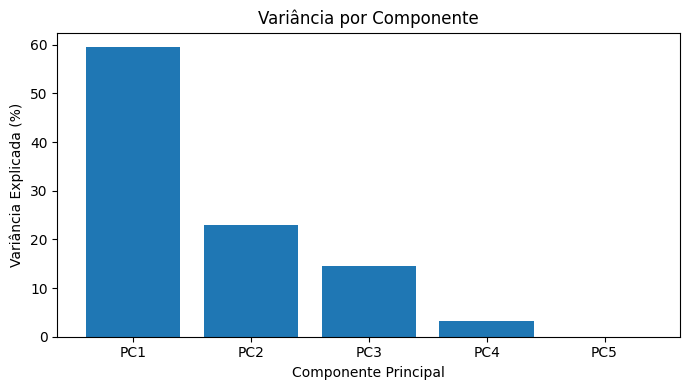

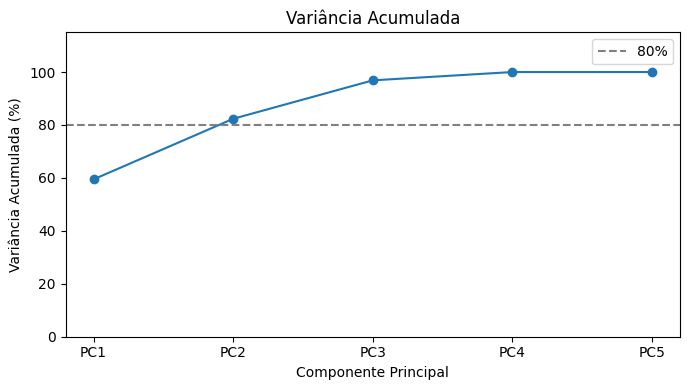


PC1 + PC2 = 82.3% da variância total


In [8]:
pca_full = PCA(n_components=len(features))
pca_full.fit(X_std)

variancias = pca_full.explained_variance_ratio_ * 100
acumulado  = variancias.cumsum()
labels_pc  = [f'PC{i+1}' for i in range(len(features))]

for i, (v, a) in enumerate(zip(variancias, acumulado)):
    print(f"PC{i+1}: {v:.2f}%   acumulado: {a:.2f}%")

plt.figure(figsize=(7, 4))
plt.bar(labels_pc, variancias)
plt.title('Variância por Componente')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(labels_pc, acumulado, marker='o')
plt.axhline(80, color='gray', linestyle='--', label='80%')
plt.title('Variância Acumulada')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Acumulada (%)')
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nPC1 + PC2 = {acumulado[1]:.1f}% da variância total")

Loadings PC1:
  qtd             +0.4637
  r_faturado      +0.5688
  r_custo         +0.4207
  r_margem        +0.4925
  preco_med       +0.2049

Loadings PC2:
  qtd             -0.4881
  r_faturado      +0.0800
  r_custo         +0.3462
  r_margem        -0.2443
  preco_med       +0.7588


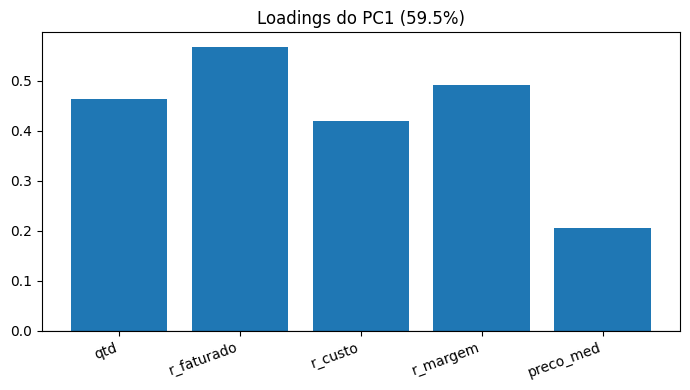

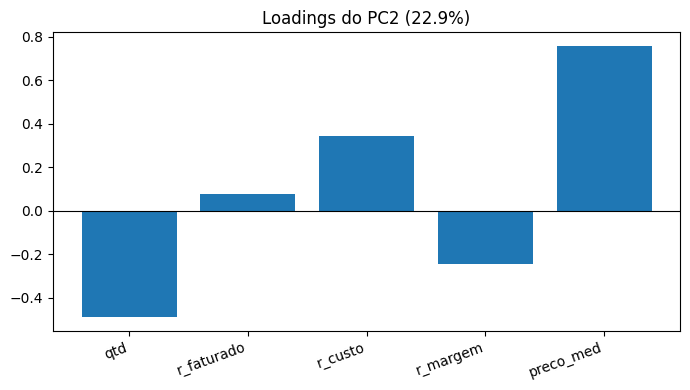

In [9]:
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_std)

var1 = pca2.explained_variance_ratio_[0] * 100
var2 = pca2.explained_variance_ratio_[1] * 100

loadings_pc1 = pca2.components_[0]
loadings_pc2 = pca2.components_[1]

print("Loadings PC1:")
for f, v in zip(features, loadings_pc1):
    print(f"  {f:<15} {v:+.4f}")

print("\nLoadings PC2:")
for f, v in zip(features, loadings_pc2):
    print(f"  {f:<15} {v:+.4f}")

plt.figure(figsize=(7, 4))
plt.bar(features, loadings_pc1)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Loadings do PC1 ({var1:.1f}%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(features, loadings_pc2)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Loadings do PC2 ({var2:.1f}%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

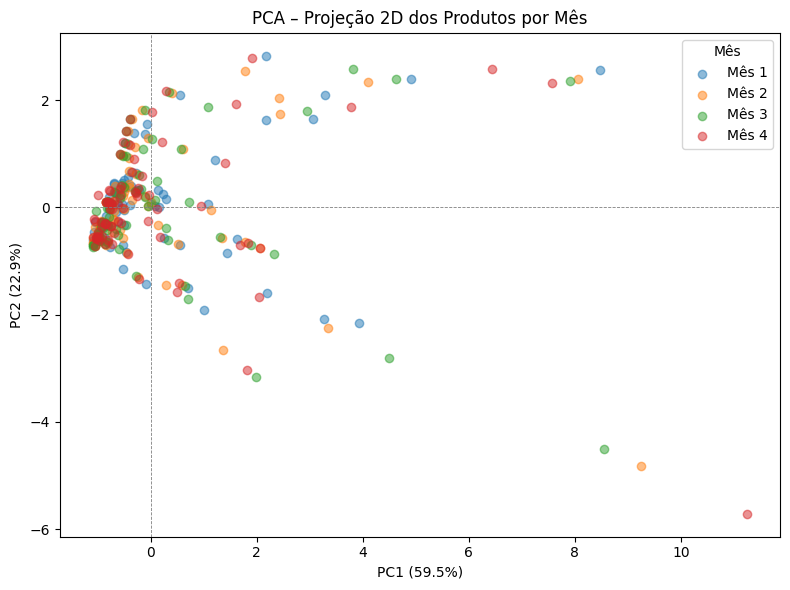

In [14]:
plt.figure(figsize=(8, 6))
for mes in sorted(df['mes'].unique()):
    mask = df['mes'] == mes
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Mês {mes}', alpha=0.5)
plt.axhline(0, color='gray', linewidth=0.6, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.6, linestyle='--')
plt.xlabel(f'PC1 ({var1:.1f}%)')
plt.ylabel(f'PC2 ({var2:.1f}%)')
plt.title('PCA – Projeção 2D dos Produtos por Mês')
plt.legend(title='Mês')
plt.tight_layout()
plt.show()

c:\Users\ndf28\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\ndf28\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\ndf28\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Stress normalizado: 0.0472


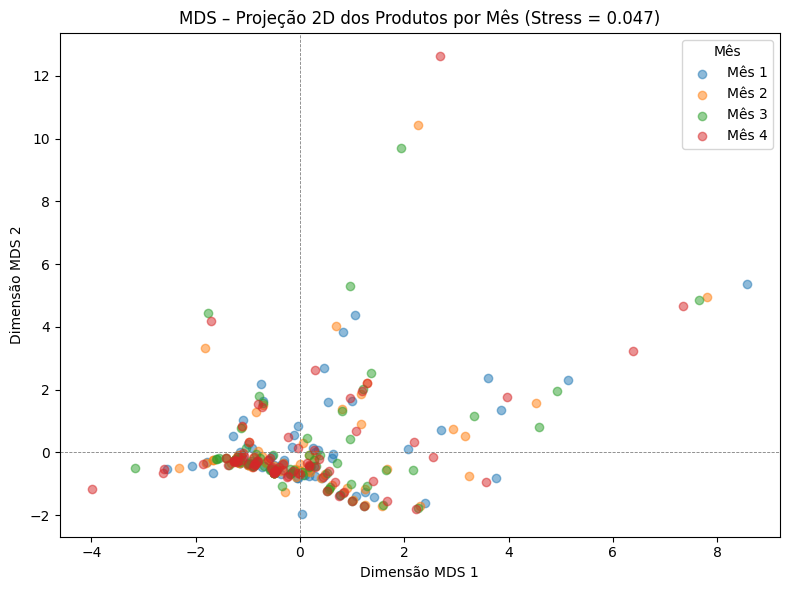

In [15]:
D = pairwise_distances(X_std, metric='euclidean')

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, max_iter=1000)
X_mds = mds.fit_transform(D)

stress_norm = np.sqrt(mds.stress_ / np.sum(D ** 2))
print(f"Stress normalizado: {stress_norm:.4f}")

plt.figure(figsize=(8, 6))
for mes in sorted(df['mes'].unique()):
    mask = df['mes'] == mes
    plt.scatter(X_mds[mask, 0], X_mds[mask, 1], label=f'Mês {mes}', alpha=0.5)
plt.axhline(0, color='gray', linewidth=0.6, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.6, linestyle='--')
plt.xlabel('Dimensão MDS 1')
plt.ylabel('Dimensão MDS 2')
plt.title(f'MDS – Projeção 2D dos Produtos por Mês (Stress = {stress_norm:.3f})')
plt.legend(title='Mês')
plt.tight_layout()
plt.show()

Outliers (mais distantes da origem no PCA):
        nome  mes  qtd  r_faturado  r_margem  dist_pca
Caneca 500mL    4  972       12545  10912.04 12.619951
Caneca 500mL    2  813       10485   9119.16 10.428518
Caneca 500mL    3  757        9765   8493.24  9.660582
    TORRE 2L    1  317       13180   2085.00  8.852935
    TORRE 2L    2  279       12555   2790.00  8.403880
    TORRE 2L    3  274       12330   2740.00  8.249858


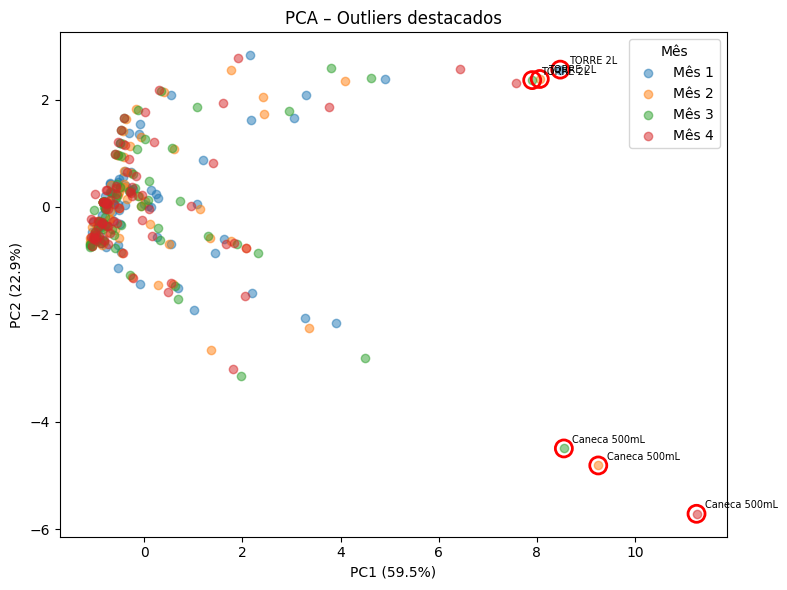

In [16]:
df['dist_pca'] = np.sqrt(X_pca[:, 0]**2 + X_pca[:, 1]**2)
top = df.nlargest(6, 'dist_pca')

print("Outliers (mais distantes da origem no PCA):")
print(top[['nome', 'mes', 'qtd', 'r_faturado', 'r_margem', 'dist_pca']].to_string(index=False))

plt.figure(figsize=(8, 6))
for mes in sorted(df['mes'].unique()):
    mask = df['mes'] == mes
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Mês {mes}', alpha=0.5)
for idx in top.index:
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=150, facecolors='none', edgecolors='red', linewidths=2)
    plt.annotate(df['nome'].iloc[idx],
                 xy=(X_pca[idx, 0], X_pca[idx, 1]),
                 xytext=(6, 4), textcoords='offset points', fontsize=7)
plt.xlabel(f'PC1 ({var1:.1f}%)')
plt.ylabel(f'PC2 ({var2:.1f}%)')
plt.title('PCA – Outliers destacados')
plt.legend(title='Mês')
plt.tight_layout()
plt.show()

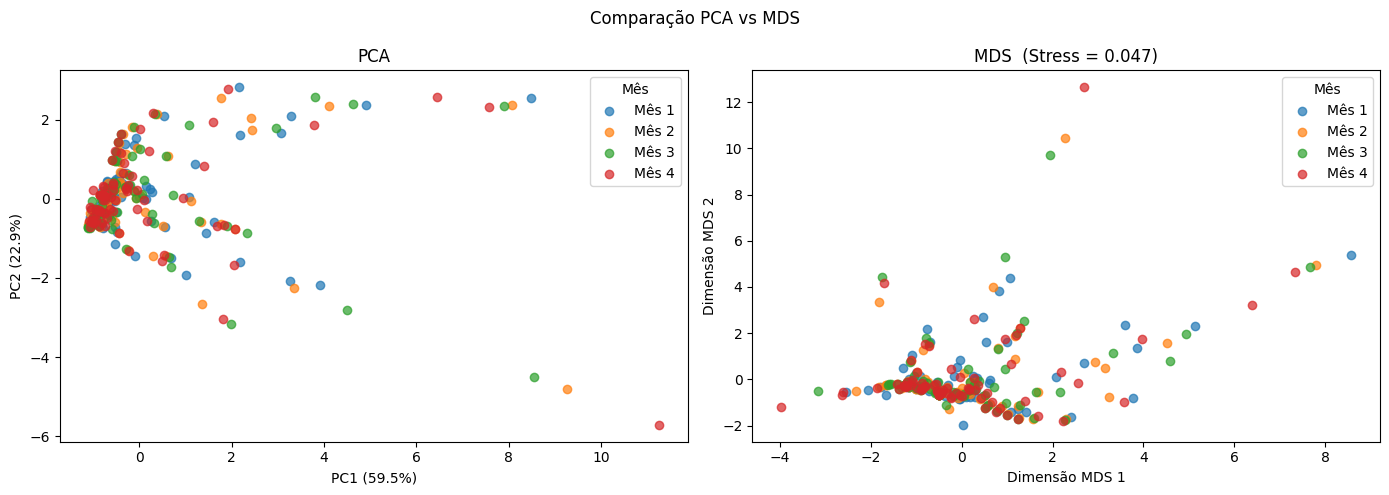

In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for mes in sorted(df['mes'].unique()):
    mask = df['mes'] == mes
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Mês {mes}', alpha=0.7)
plt.xlabel(f'PC1 ({var1:.1f}%)')
plt.ylabel(f'PC2 ({var2:.1f}%)')
plt.title('PCA')
plt.legend(title='Mês')

plt.subplot(1, 2, 2)
for mes in sorted(df['mes'].unique()):
    mask = df['mes'] == mes
    plt.scatter(X_mds[mask, 0], X_mds[mask, 1], label=f'Mês {mes}', alpha=0.7)
plt.xlabel('Dimensão MDS 1')
plt.ylabel('Dimensão MDS 2')
plt.title(f'MDS  (Stress = {stress_norm:.3f})')
plt.legend(title='Mês')

plt.suptitle('Comparação PCA vs MDS')
plt.tight_layout()
plt.show()